# Notebook 01 — Data Loading & Cleaning
## Sections 1 & 2: Data Preprocessing

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
import re

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

DATA_DIR = Path("data")
OUTPUTS_DIR = Path("outputs")
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## 1. Load All 35 Excel Files

In [23]:
dfs = []
for i in range(1, 36):
    path = DATA_DIR / f"avis_{i}_traduit.xlsx"
    if path.exists():
        df = pd.read_excel(path)
        dfs.append(df)
    else:
        print(f"Missing: {path}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows before filtering: {len(df)}")

# Drop reviews with no star rating
df = df.dropna(subset=['note'])
print(f"Rows after dropping reviews without stars: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Total rows before filtering: 34435
Rows after dropping reviews without stars: 24104
Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en']


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN


In [24]:
# Basic stats
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Shape: (24104, 11)

Missing values:
note                    0
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 1
avis_cor            24104
avis_cor_en         24104
dtype: int64

Data types:
note                float64
auteur               object
avis                 object
assureur             object
produit              object
type                 object
date_publication     object
date_exp             object
avis_en              object
avis_cor             object
avis_cor_en          object
dtype: object


## 2. Create Text Column (English Only)

In [25]:
# Use avis_cor_en with fallback to avis_en
df['text'] = df['avis_cor_en'].fillna(df['avis_en'])

# Drop rows with no text
df = df[df['text'].notna() & (df['text'].str.strip() != '')]
print(f"Rows after dropping empty text: {len(df)}")

# Clean text: strip whitespace
df['text'] = df['text'].str.strip()
df.head(3)[['avis', 'avis_en', 'avis_cor_en', 'text']]

Rows after dropping empty text: 24103


,avis,avis_en,avis_cor_en,text
0,"Meilleurs assurances, prix, solutions, écoute,...","Best insurance, price, solutions, listening, s...",NaN,"Best insurance, price, solutions, listening, s..."
1,"je suis globalement satisfait , sauf que vous ...","I am generally satisfied, except that you have...",NaN,"I am generally satisfied, except that you have..."
2,Prix tres abordable plusieurs options s'offren...,Very affordable price Several options are avai...,NaN,Very affordable price Several options are avai...


## 3. Derive Labels

In [26]:
# Sentiment from note
def note_to_sentiment(note):
    try:
        note = float(note)
        if note <= 2:
            return 'negative'
        elif note == 3:
            return 'neutral'
        else:
            return 'positive'
    except:
        return None

df['sentiment'] = df['note'].apply(note_to_sentiment)
df = df[df['sentiment'].notna()]

print("Sentiment distribution:")
print(df['sentiment'].value_counts())

# Star rating as integer
df['star_rating'] = df['note'].astype(int)

Sentiment distribution:
sentiment
negative    10987
positive     9734
neutral      3382
Name: count, dtype: int64


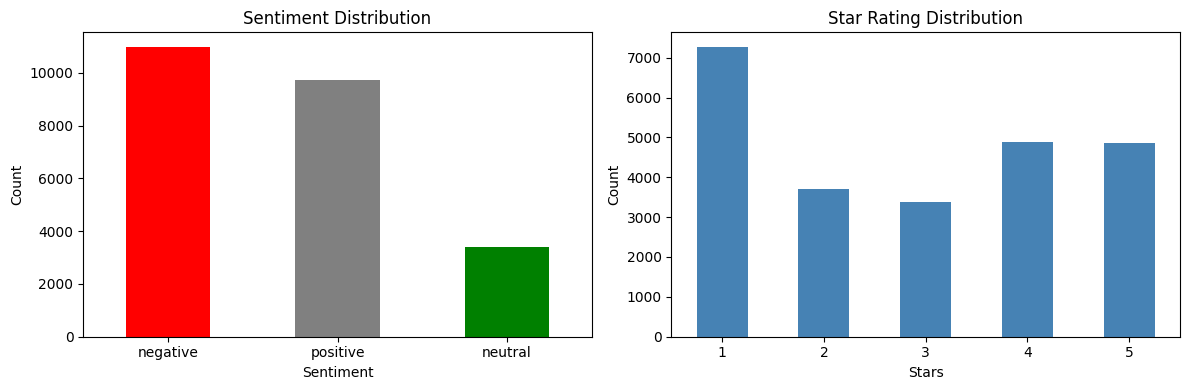

Saved label_distribution.png


In [27]:
# Plot sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['red','gray','green'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

df['star_rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Star Rating Distribution')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'label_distribution.png', dpi=100)
plt.show()
print("Saved label_distribution.png")

## 4. Category Labels via Zero-Shot Classification

In [28]:
import torch
from transformers import pipeline

CATEGORIES = ['Pricing', 'Coverage', 'Enrollment', 'Customer Service', 'Claims Processing', 'Cancellation']

print("Loading lightning-fast zero-shot classifier...")

# 1. We swap to DistilBERT (6 layers instead of BART's 24 layers)
# 2. We add torch.float16 to run operations 2x faster natively on Mac
classifier = pipeline(
    "zero-shot-classification", 
    model="typeform/distilbert-base-uncased-mnli", 
    device="mps",
    torch_dtype=torch.float16
)
print("Classifier loaded.")

Loading lightning-fast zero-shot classifier...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Classifier loaded.


In [29]:
from tqdm import tqdm

# To keep runtime manageable, classify all reviews in batches
# For a large dataset, we sample if needed but try all
BATCH_SIZE = 32

def classify_batch(texts, categories):
    results = classifier(texts, categories, multi_label=False)
    return [r['labels'][0] for r in results]

print(f"Classifying {len(df)} reviews into categories...")
categories_list = []

texts = df['text'].tolist()
for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i:i+BATCH_SIZE]
    cats = classify_batch(batch, CATEGORIES)
    categories_list.extend(cats)

df['category'] = categories_list
print("Category distribution:")
print(df['category'].value_counts())

Classifying 24103 reviews into categories...


100%|██████████| 754/754 [19:28<00:00,  1.55s/it]

Category distribution:
category
Pricing              10013
Coverage              6126
Customer Service      4321
Claims Processing     1492
Cancellation          1430
Enrollment             721
Name: count, dtype: int64


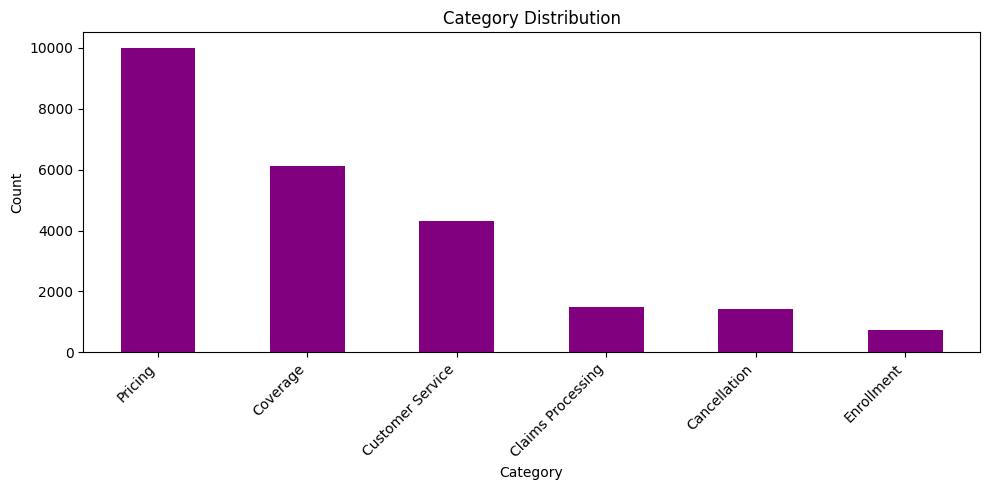

In [30]:
# Plot category distribution
plt.figure(figsize=(10, 5))
df['category'].value_counts().plot(kind='bar', color='purple')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'category_distribution.png', dpi=100)
plt.show()

## 5. Frequent Words & N-gram Analysis

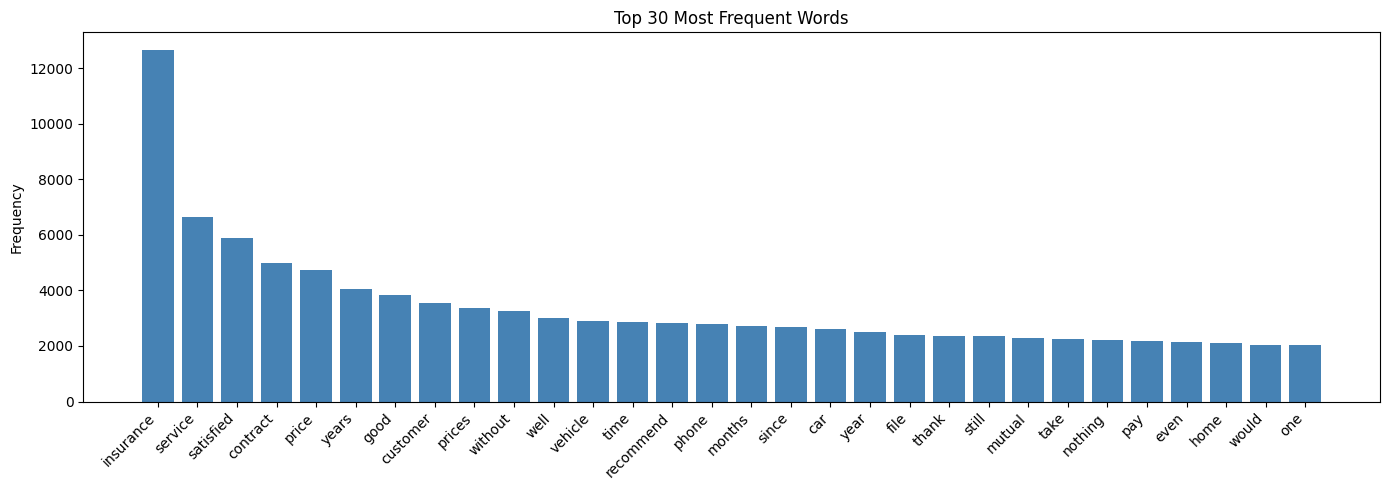

In [31]:
STOP_WORDS = set(stopwords.words('english'))

def tokenize(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha() and t not in STOP_WORDS and len(t) > 2]
    return tokens

all_tokens = []
for text in df['text']:
    all_tokens.extend(tokenize(text))

# Unigrams
word_freq = Counter(all_tokens)
top_words = word_freq.most_common(30)
words, counts = zip(*top_words)

plt.figure(figsize=(14, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 30 Most Frequent Words')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'top_words.png', dpi=100)
plt.show()

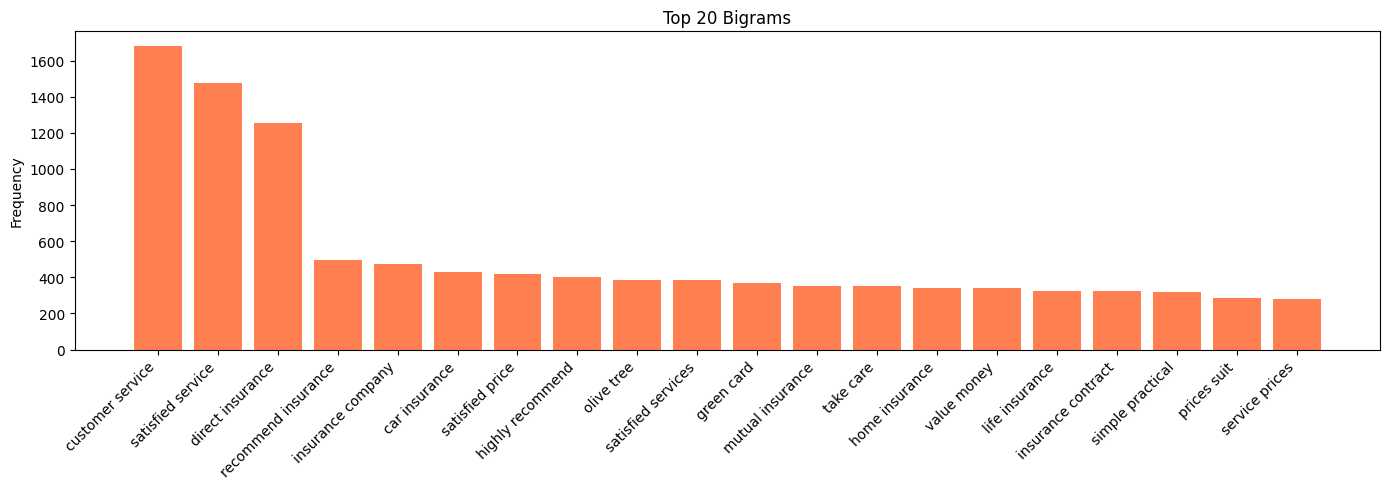

In [32]:
# Bigrams
bigram_list = []
for text in df['text']:
    tokens = tokenize(text)
    bigram_list.extend(ngrams(tokens, 2))

bigram_freq = Counter(bigram_list)
top_bigrams = bigram_freq.most_common(20)
bg_words = [' '.join(bg) for bg, _ in top_bigrams]
bg_counts = [c for _, c in top_bigrams]

plt.figure(figsize=(14, 5))
plt.bar(bg_words, bg_counts, color='coral')
plt.title('Top 20 Bigrams')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'top_bigrams.png', dpi=100)
plt.show()

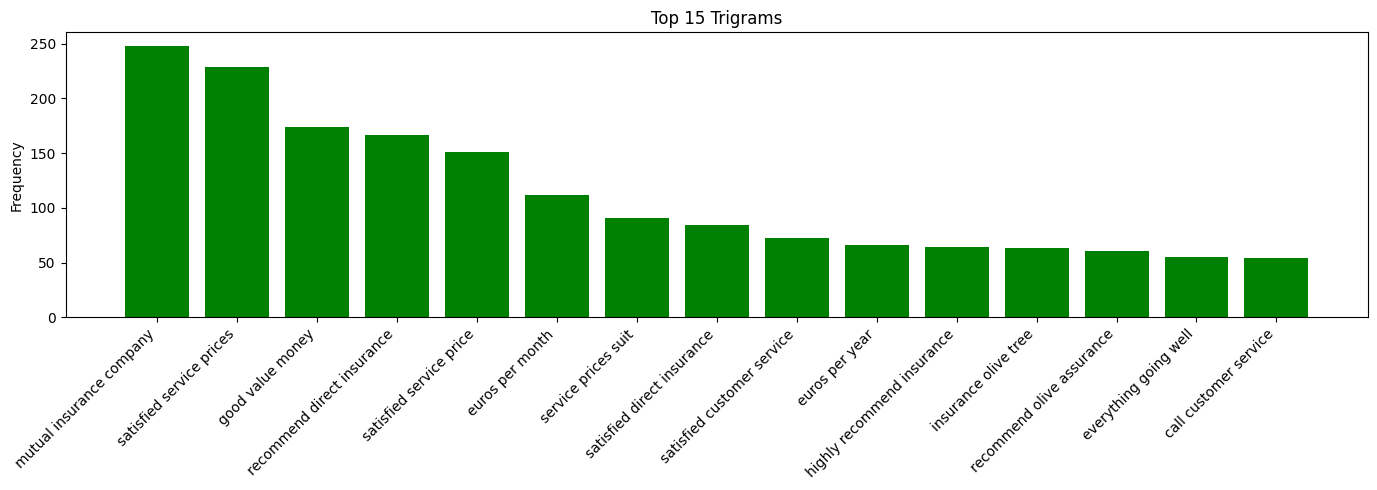

In [33]:
# Trigrams
trigram_list = []
for text in df['text']:
    tokens = tokenize(text)
    trigram_list.extend(ngrams(tokens, 3))

trigram_freq = Counter(trigram_list)
top_trigrams = trigram_freq.most_common(15)
tg_words = [' '.join(tg) for tg, _ in top_trigrams]
tg_counts = [c for _, c in top_trigrams]

plt.figure(figsize=(14, 5))
plt.bar(tg_words, tg_counts, color='green')
plt.title('Top 15 Trigrams')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'top_trigrams.png', dpi=100)
plt.show()

## 6. Spelling Correction Comparison

In [35]:
_dfs = []
for i in range(1, 36):
    _path = DATA_DIR / f"avis_{i}_traduit.xlsx"
    if _path.exists():
        _dfs.append(pd.read_excel(_path))

_df_raw = pd.concat(_dfs, ignore_index=True)
_spell_sample = _df_raw[_df_raw['avis_cor_en'].notna() & _df_raw['avis_en'].notna()]

print(f"Spelling correction rows available: {len(_spell_sample)}")
sample = _spell_sample.sample(min(10, len(_spell_sample)), random_state=42)
print("Spelling Correction Examples (avis_en → avis_cor_en):\n")
for _, row in sample.iterrows():
    orig = str(row['avis_en'])[:100]
    corr = str(row['avis_cor_en'])[:100]
    if orig != corr:
        print(f"Original: {orig}")
        print(f"Corrected: {corr}")
        print("---")

Spelling correction rows available: 431
Spelling Correction Examples (avis_en → avis_cor_en):



## 7. Save Cleaned DataFrame

In [36]:
# Select relevant columns
KEEP_COLS = ['note', 'auteur', 'avis', 'assureur', 'produit', 'type',
             'date_publication', 'date_exp', 'avis_en', 'avis_cor_en',
             'text', 'sentiment', 'star_rating', 'category']

# Keep only columns that exist
keep = [c for c in KEEP_COLS if c in df.columns]
df_clean = df[keep].reset_index(drop=True)

df_clean.to_csv(OUTPUTS_DIR / 'reviews_clean.csv', index=False)
print(f"Saved {len(df_clean)} reviews to outputs/reviews_clean.csv")
print(df_clean[['text', 'sentiment', 'star_rating', 'category']].head())

Saved 24103 reviews to outputs/reviews_clean.csv
                                                text sentiment  star_rating  \
0  Best insurance, price, solutions, listening, s...  positive            5   
1  I am generally satisfied, except that you have...  positive            4   
2  Very affordable price Several options are avai...  positive            5   
3  I satisfy the service, a very fast response fr...  positive            4   
4  Customer for more than 25 years, very disappoi...  negative            1   

           category  
0           Pricing  
1          Coverage  
2           Pricing  
3  Customer Service  
4           Pricing  


## 8. Train/Test Split

In [37]:
from sklearn.model_selection import train_test_split

# Stratify on sentiment (most used target)
train_df, test_df = train_test_split(
    df_clean, test_size=0.2, random_state=42, stratify=df_clean['sentiment']
)
train_df.to_csv(OUTPUTS_DIR / 'train.csv', index=False)
test_df.to_csv(OUTPUTS_DIR / 'test.csv', index=False)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print("\nTrain sentiment distribution:")
print(train_df['sentiment'].value_counts())
print("\nTest sentiment distribution:")
print(test_df['sentiment'].value_counts())

Train: 19282 | Test: 4821

Train sentiment distribution:
sentiment
negative    8789
positive    7787
neutral     2706
Name: count, dtype: int64

Test sentiment distribution:
sentiment
negative    2198
positive    1947
neutral      676
Name: count, dtype: int64


## Summary
- Loaded all 35 Excel files into a single DataFrame
- Created `text` column from `avis_cor_en` (fallback: `avis_en`)
- Derived `sentiment` from `note` (1-2=negative, 3=neutral, 4-5=positive)
- Assigned `category` via zero-shot classification
- Analyzed frequent words and n-grams
- Saved `outputs/reviews_clean.csv`, `outputs/train.csv`, `outputs/test.csv`